# vader

> Sentiment estimator and feature extractor using VADER.

Textplumber implements a sentiment estimator and feature extraction using [VADER](https://github.com/cjhutto/vaderSentiment), "a lexicon and rule-based sentiment analysis tool". [VADER's GitHub repository](https://github.com/cjhutto/vaderSentiment) and [Hutto and Gilbert's 2014 paper about VADER](https://ojs.aaai.org/index.php/ICWSM/article/view/14550) are the best explanation of VADER and how the VADER lexicon and rules were derived.   

This functionality required Textplumber version 0.0.9 or above. 

Note: Two experimental components are provided to extract sentiment scores across a document or extract POS-ngrams tagged with sentiment. These experimental components are likely to change. 

In [ ]:
#| default_exp vader

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export
from __future__ import annotations
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from textplumber.store import TextFeatureStore
from textplumber.core import pass_tokens
from vaderSentiment.vaderSentiment import *
import numpy as np
from fastcore.basics import patch
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from IPython.display import HTML, display
from wordcloud import WordCloud
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#| hide
from datasets import load_dataset
from textplumber.report import plot_confusion_matrix, get_label_names, save_results, plot_logistic_regression_features_from_pipeline

## Textplumber components to extract features or score texts using VADER

In [ ]:
#| export
class VaderSentimentExtractor(BaseEstimator, TransformerMixin):
	""" Sci-kit Learn pipeline component to extract sentiment features using VADER. """
	def __init__(self, 
			  feature_store:TextFeatureStore = None, # (not implemented currently)
			  output:str = 'polarity', # 'polarity' (VADER's compound score), 'proportions' (ratios for proportions of text that are positive, neutral or negative), or 'allstats' (equivalent to 'polarity' + 'proportions'), 'labels' (positive, neutral, negative)
			  neutral_threshold:float = 0.05, # threshold for neutral sentiment
			):
		
		self.feature_store = feature_store
		if output not in ['polarity', 'proportions', 'allstats', 'labels']: # note: 'profileallstats' is experimental and not listed in the docs
			raise ValueError(f"output must be one of ['polarity', 'proportions', 'allstats', 'labels'], got {output}")
		self.output = output
		self.neutral_threshold = neutral_threshold

		self.analyzer_ = SentimentIntensityAnalyzer()

By default `neutral_threshold` is set to 0.05. This means that any text with polarity greater than -0.05 and less than 0.05 will be 'neutral'. The 0.05 value default is the recommendation of the [VADER Github page](https://github.com/cjhutto/vaderSentiment?tab=readme-ov-file#about-the-scoring), but this can be tuned as needed. 

In [ ]:
#| export
@patch
def fit(self:VaderSentimentExtractor, X, y=None):
	""" Fit is implemented, but does nothing. """
	return self

In [ ]:
#| export
@patch
def convert_score_to_label(self:VaderSentimentExtractor, score: float, label_mapping = None) -> str:
	""" Convert VADER score to label. """
	if score >= self.neutral_threshold:
		label = 'positive'
	elif score <= self.neutral_threshold * -1:
		label = 'negative'
	else:
		label = 'neutral'
	if label_mapping is not None:
		label = label_mapping[label]
	return label

In [ ]:
#| export
@patch
def convert_scores_to_labels(self:VaderSentimentExtractor, scores: list[float], label_mapping = None):
	""" Convert VADER score to label. """
	for score in scores:
		yield self.convert_score_to_label(score)

In [ ]:
#| export
@patch
def transform(self:VaderSentimentExtractor, X):
	""" Extracts the sentiment from the text using VADER. """
	results = []
	for text in X:
		scores = self.analyzer_.polarity_scores(text)
		if self.output == 'proportions':
			results.append([scores['pos'], scores['neu'], scores['neg']])
		elif self.output == 'labels':
			compound = scores['compound']
			results.append(self.convert_score_to_label(compound))
		elif self.output == 'allstats':
			results.append([scores['pos'], scores['neu'], scores['neg'], scores['compound']])
		else: # default
			results.append([scores['compound']])
	return np.atleast_2d(results)  # Ensure the output is always a 2D array

In [ ]:
#| export
@patch
def get_feature_names_out(self:VaderSentimentExtractor, input_features=None):
	""" Get the feature names out from the model. """
	if self.output == 'proportions':
		return ['positive', 'neutral', 'negative']
	elif self.output == 'labels':
		return ['label']
	elif self.output == 'allstats':
		return ['positive', 'neutral', 'negative', 'compound']
	else: # default
		return ['polarity']


In [ ]:
#| hide
vader_extractor = VaderSentimentExtractor(output = 'labels')
vader_extractor.fit(['Hello, world! Today is great!'])
assert vader_extractor.get_feature_names_out() == ['label']
assert vader_extractor.transform(['Hello, world! Today is great!']) == ['positive']
vader_extractor = VaderSentimentExtractor(output = 'proportions')
vader_extractor.fit(['Hello, world! Today is great!'])
assert vader_extractor.get_feature_names_out() == ['positive', 'neutral', 'negative']
test_texts = ['good, good, good, good', 'bad, bad, bad, bad', 'fish, cat, box, dog']
assert tuple(vader_extractor.transform(test_texts)[0]) == tuple([1.0, 0.0, 0.0])
assert tuple(vader_extractor.transform(test_texts)[1]) == tuple([0.0, 0.0, 1.0])
assert tuple(vader_extractor.transform(test_texts)[2]) == tuple([0.0, 1.0, 0.0])
vader_extractor = VaderSentimentExtractor(output = 'polarity')
assert vader_extractor.get_feature_names_out() == ['polarity']
assert vader_extractor.transform(test_texts)[0] > 0.05
assert vader_extractor.transform(test_texts)[1] < -0.05
assert vader_extractor.transform(test_texts)[2] == 0

del vader_extractor


In [ ]:
#| export
class VaderSentimentEstimator(VaderSentimentExtractor, ClassifierMixin):
	""" Sci-kit Learn pipeline component to predict sentiment using VADER. """

	def __init__(self,
				 output:str = 'labels', # 'polarity' (VADER's compound score) or 'labels' (positive, neutral, negative)
				 neutral_threshold:float = 0.05, # threshold for neutral sentiment (see note for VaderSentimentExtractor)
				 label_mapping:dict|None = None, # (ignored if labels is None) mapping of labels to desired labels - keys should be 'positive', 'neutral', 'negative' and values should be desired labels
				 ):
		
		super().__init__()
		if output not in ['polarity', 'labels']:
			raise ValueError(f"output must be one of ['polarity', 'labels'], got {output}")
		self.output = output
		self.label_mapping = label_mapping
		self.neutral_threshold = neutral_threshold

If `output` is set to `labels` then `VaderSentimentEstimator` functions as a pseudo-classifier. With `output` set to `polarity`, it functions as a regressor or scorer.

By default the VaderSentimentEstimator is setup to work with three classes (i.e. it returns 'positive', 'neutral' or 'negative'). If you only have two classes (negative/positive), set the neutral_threshold to 0 to remove the neutral class. Even slightly negative or positive scores will be assigned a non-neutral label. A 0 polarity score will be assigned to positive in the two-class case. The classes might be better interpreted as negative and not-negative in this instance.

	neutral_threshold = 0

You may also want/need to create a label mapping so that the correct class IDs are returned by the estimator.  

For example ...

	label_mapping = {
		'positive': 1,
		'negative': 0
	}



In [ ]:
#| export
@patch
def predict(self:VaderSentimentEstimator, X):
	""" Predict the sentiment of texts using VADER. """
	y_predicted = self.transform(X).ravel()
	if self.output == 'labels' and self.label_mapping is not None:
		for i, prediction in enumerate(y_predicted):
			y_predicted[i] = self.label_mapping[prediction]
		dtype = type(list(self.label_mapping.values())[0])
	elif self.output == 'labels':
		dtype = str
	else:
		dtype = float
	return np.array(y_predicted, dtype=dtype)

In [ ]:
#| hide
vader_estimator = VaderSentimentEstimator(output = 'labels')
test_texts = ['good, good, good, good', 'bad, bad, bad, bad', 'fish, cat, box, dog']
vader_estimator.fit(test_texts)
assert tuple(vader_estimator.predict(test_texts)) == tuple(['positive', 'negative', 'neutral'])

vader_estimator = VaderSentimentEstimator(output = 'labels')
vader_estimator.fit(test_texts)
assert tuple(vader_estimator.predict(test_texts)) == tuple(['positive', 'negative', 'neutral'])

vader_estimator = VaderSentimentEstimator(output = 'labels', label_mapping = {'positive': 2, 'neutral': 1, 'negative': 0})
vader_estimator.fit(test_texts)
assert tuple(vader_estimator.predict(test_texts)) == tuple([2, 0, 1])

# two class example # i.e. negative or not-negative
vader_estimator = VaderSentimentEstimator(output = 'labels', neutral_threshold=0, label_mapping = {'positive': 1, 'negative': 0})
vader_estimator.fit(test_texts)
assert tuple(vader_estimator.predict(test_texts)) == tuple([1, 0, 1]) 

vader_estimator = VaderSentimentEstimator(output = 'polarity')
vader_estimator.fit(test_texts)
assert vader_estimator.predict(test_texts)[0] > 0.05
assert vader_estimator.predict(test_texts)[1] < -0.05
assert vader_estimator.predict(test_texts)[2] == 0

del vader_estimator


## Example using VADER as an estimator

Here is an example demonstrating how to use `VaderSentimentEstimator` in a pipeline. 

In [ ]:
#| hide
import os

In [ ]:
#| eval: false
from datasets import load_dataset
from textplumber.report import plot_confusion_matrix, get_label_names, save_results, plot_logistic_regression_features_from_pipeline

from textplumber.vader import VaderSentimentEstimator, VaderSentimentExtractor
from textplumber.preprocess import SpacyPreprocessor
from textplumber.embeddings import Model2VecEmbedder
from textplumber.core import get_stop_words

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

from sklearn.model_selection import train_test_split

In [ ]:
#| hide
if os.path.exists('feature_store_example_vader.sqlite'):
	os.remove('feature_store_example_vader.sqlite')

In [ ]:
#| hide
if os.path.exists('results_example_vader.csv'):
	os.remove('results_example_vader.csv')
if os.path.exists('results_example_vader_profiles.csv'):
	os.remove('results_example_vader_profiles.csv')

Here we load text samples from a [sentiment dataset](https://huggingface.co/datasets/cardiffnlp/tweet_eval). The dataset has validation and test sets, but we are just working with the train split in this instance.

In [ ]:
#| eval: false
dataset_name = 'cardiffnlp/tweet_eval'
dataset_dir = 'sentiment'
dataset = load_dataset(dataset_name, data_dir = dataset_dir, split='train')

Only getting 5000 for each class ...

In [ ]:
#| eval: false
label_column = 'label'
target_names = get_label_names(dataset, label_column)
target_classes = list(range(len(target_names)))

# selecting 5000 per class here ...
df = dataset.to_pandas()
sampled_dfs = [
    group.sample(n=5000, random_state=42)
    for _, group in df.groupby('label')
]
df = pd.concat(sampled_dfs, ignore_index=True)

X = df['text']
y = df[label_column]

In [ ]:
#| eval: false
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
#| eval: false
pd.set_option('display.max_colwidth', 200)
df = pd.DataFrame({'text': X_train, 'label': y_train})
df['label_name'] = df['label'].apply(lambda x: target_names[x])
df.head(5)

,text,label,label_name
5497,Harper walks. #Nats now have two men on with one out. Escobar will bat next. Still 8-7 Mets in the bottom of the 9th.,1,neutral
12677,May or may not be getting ready to watch the very first season EVER of Big Brother. @user I'm so ready to see what Julie looks like!,2,positive
8037,Patrick Leahy & Christian Bale together again. U.S. Senator to make his 2nd cameo in Batman movie in Dark Knight Rises,1,neutral
6670,"""A smartphone review that the tech press needs to read twice, obviously great for consumers too: Moto G 3rd gen review",1,neutral
79,"Armed with the tools of power &amp; intimidation Harper is trying to steal our country. On October 19th, armed with pencils LET'S TAKE IT BACK.",0,negative


Setup a label mapping so that the label values that match the dataset are returned rather than the default 'positive', 'neutral', 'negative' labels returned by `VaderSentimentEstimator`.

In [ ]:
#| eval: false
label_mapping = {
	'negative': 0,
	'neutral': 1, 
	'positive': 2
}

Our pipeline only has one component! Notice that the label_mapping is passed to the estimator to ensure we return comparable labels to the data-set labels.

In [ ]:
#| eval: false
pipeline = Pipeline([
    ('vader_estimator', VaderSentimentEstimator(output = 'labels', label_mapping = label_mapping)),
], verbose=True)

display(pipeline)

,steps,"[('vader_estimator', ...)]"
,transform_input,None
,memory,None
,verbose,True
,output,'labels'
,neutral_threshold,0.05
,label_mapping,"{'negative': 0, 'neutral': 1, 'positive': 2}"


Note: VADER is based on a lexicon and heuristics that are independent of the training data. The fit call is not really required below (and it does nothing). 

In [ ]:
#| eval: false
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

[Pipeline] ... (step 1 of 1) Processing vader_estimator, total=   0.0s


Log some results for the final cell summary.

In [ ]:
#| eval: false
dataset_descriptor = 'tweet_eval sentiment dataset, 5000 rows per class randomly sampled from train split (per class - 4000 train, 1000 test)'
experiment_descriptor = 'Assigning labels using VADER'
results = save_results('results_example_vader.csv', pipeline, experiment_descriptor, dataset_descriptor, y_test, y_pred, target_classes, target_names, classifier_step_name = 'vader_estimator')

Here are the results ...

In [ ]:
#| eval: false
print(classification_report(y_test, y_pred, labels = target_classes, target_names = target_names, digits=3))
plot_confusion_matrix(y_test, y_pred, target_classes, target_names)

              precision    recall  f1-score   support

    negative      0.657     0.591     0.622      1000
     neutral      0.533     0.392     0.452      1000
    positive      0.514     0.702     0.594      1000

    accuracy                          0.562      3000
   macro avg      0.568     0.562     0.556      3000
weighted avg      0.568     0.562     0.556      3000



## Example using VADER as a feature extractor

Here is an example demonstrating how to use `VaderSentimentExtractor` in a pipeline. We will use the same dataset as above so we can compare results between predictions based on VADER and the predictions of a machine learning model that uses VADER statistics as features.

The VaderSentimentExtractor can return VADER's compound polarity score ('polarity'), proportions of positive/neutral/negative ('proportions'), or all statistics ('allstats').  

Note: when proportions are being returned by VADER, these do not make use of rules reflected in the compound polarity score. See [VADER's Github documentation](https://github.com/cjhutto/vaderSentiment?tab=readme-ov-file#about-the-scoring) for more information. 

In [ ]:
#| eval: false
pipeline = Pipeline([
    ('vader_extractor', VaderSentimentExtractor(output = 'allstats')),
    ('classifier', LogisticRegression(max_iter = 5000, random_state=55))
], verbose=True)

display(pipeline)

,steps,"[('vader_extractor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,True
,feature_store,None
,output,'allstats'
,neutral_threshold,0.05
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [ ]:
#| eval: false
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

[Pipeline] ... (step 1 of 2) Processing vader_extractor, total=   1.0s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=   0.2s


Logging results for summary ...

In [ ]:
#| eval: false
experiment_descriptor = 'Logistic Regression classifier using VADER features'
results = save_results('results_example_vader.csv', pipeline, experiment_descriptor, dataset_descriptor, y_test, y_pred, target_classes, target_names, classifier_step_name = 'classifier')

As might be expected, the performance of a classifier based on statistical output from VADER is similar to the results of the first experiment, which used VADER to assign the class ... 

In [ ]:
#| eval: false
print(classification_report(y_test, y_pred, labels = target_classes, target_names = target_names, digits=3))
plot_confusion_matrix(y_test, y_pred, target_classes, target_names)

              precision    recall  f1-score   support

    negative      0.660     0.632     0.646      1000
     neutral      0.527     0.493     0.510      1000
    positive      0.570     0.631     0.599      1000

    accuracy                          0.585      3000
   macro avg      0.586     0.585     0.585      3000
weighted avg      0.586     0.585     0.585      3000



It is anticipated that the VaderSentimentExtractor component will be used alongside other features. Here is an example where the VADER statistics are supplemented by other features.

Setup a feature store to save preprocessed texts ...

In [ ]:
#| eval: false
feature_store = TextFeatureStore('feature_store_example_vader.sqlite')

Augment the VADER features with embeddings ...

In [ ]:
#| eval: false
pipeline = Pipeline([
		('preprocess', SpacyPreprocessor(feature_store=feature_store)),
		('features', FeatureUnion([
				('vader', VaderSentimentExtractor(output = 'allstats')),
				('embeddings', Model2VecEmbedder(feature_store=feature_store)),
		], verbose=True)),
		('classifier', LogisticRegression(max_iter = 5000, random_state=55)),
], verbose=True)

display(pipeline)

,steps,"[('preprocess', ...), ('features', ...), ...]"
,transform_input,None
,memory,None
,verbose,True
,feature_store,<textplumber....x7f6d2bf01d90>
,pos_tagset,'simple'
,model_name,'en_core_web_sm'
,disable,"['parser', 'ner']"
,enable,['sentencizer']
,batch_size,200
,n_process,1


In [ ]:
#| eval: false
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

[Pipeline] ........ (step 1 of 3) Processing preprocess, total=  27.7s
[FeatureUnion] ......... (step 1 of 2) Processing vader, total=   1.1s
[FeatureUnion] .... (step 2 of 2) Processing embeddings, total=   1.6s
[Pipeline] .......... (step 2 of 3) Processing features, total=   2.7s
[Pipeline] ........ (step 3 of 3) Processing classifier, total=   8.0s


Logging results for summary ...

In [ ]:
#| eval: false
experiment_descriptor = 'Logistic Regression classifier using VADER features and Model2Vec embeddings'
results = save_results('results_example_vader.csv', pipeline, experiment_descriptor, dataset_descriptor, y_test, y_pred, target_classes, target_names, classifier_step_name = 'classifier')

In [ ]:
#| eval: false
print(classification_report(y_test, y_pred, labels = target_classes, target_names = target_names, digits=3))
plot_confusion_matrix(y_test, y_pred, target_classes, target_names)

              precision    recall  f1-score   support

    negative      0.704     0.725     0.714      1000
     neutral      0.594     0.574     0.584      1000
    positive      0.663     0.666     0.665      1000

    accuracy                          0.655      3000
   macro avg      0.654     0.655     0.654      3000
weighted avg      0.654     0.655     0.654      3000



Do the VADER statistics contribute to the accuracy? In other words, could we remove the VADER stats for similar performance? This sanity check is run in the next cell. Results are shown in the results summary.

In [ ]:
#| eval: false
pipeline = Pipeline([
		('preprocess', SpacyPreprocessor(feature_store=feature_store)),
		('features', FeatureUnion([
				('embeddings', Model2VecEmbedder(feature_store=feature_store)),
		], verbose=True)),
		('classifier', LogisticRegression(max_iter = 5000, random_state=55)),
], verbose=True)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

experiment_descriptor = 'Logistic Regression classifier using only Model2Vec embeddings (Sanity Check)'
results = save_results('results_example_vader.csv', pipeline, experiment_descriptor, dataset_descriptor, y_test, y_pred, target_classes, target_names, classifier_step_name = 'classifier')

[Pipeline] ........ (step 1 of 3) Processing preprocess, total=   1.7s
[FeatureUnion] .... (step 1 of 1) Processing embeddings, total=   2.4s
[Pipeline] .......... (step 2 of 3) Processing features, total=   2.4s
[Pipeline] ........ (step 3 of 3) Processing classifier, total=   5.9s


Results for the four experiments are shown below. The best model achieves an F1 score of 0.655. While much better performance is possible for sentiment classification and only a small amount of training data was used, the model with VADER statistics *and* embeddings outperformed:  

* a model trained on embeddings alone  
* a model trained on VADER's statistical output  
* the predictions of the VADER algorithm itself.


In [ ]:
#| eval: false
fields = ['experiment', 'accuracy_f1', 'negative_f1', 'neutral_f1', 'positive_f1']
display(pd.read_csv('results_example_vader.csv').sort_values(by='accuracy_f1', ascending=False)[fields])

,experiment,accuracy_f1,negative_f1,neutral_f1,positive_f1
2,Logistic Regression classifier using VADER features and Model2Vec embeddings,0.655000,0.714286,0.583927,0.664671
3,Logistic Regression classifier using only Model2Vec embeddings (Sanity Check),0.634333,0.680997,0.559836,0.659023
1,Logistic Regression classifier using VADER features,0.585333,0.645557,0.509561,0.598956
0,Assigning labels using VADER,0.561667,0.622105,0.451873,0.593658


## Experimental: Textplumber functionality to aide interpretation of VADER scores

*Note: this functionality will be released in Textplumber 0.0.10. To use it before this version is released, install Textplumber from the Github repository.* 

Textplumber includes functionality to aide interpretation of VADER's scoring of individual texts, and functionality to visualize the salience of VADER lexicon words across multiple texts. This functionality is currently added in a form that may change in the future. There may be breaking changes related to this functionality in future releases, but it available for use now.  
 
The functionality in this section was developed for the following paper:  

Moses, J., Ford, G. See Spot save lives: fear, humanitarianism, and war in the development of robot quadrupeds. Digital War 2, 64–76 (2021). [https://doi.org/10.1057/s42984-021-00037-y](https://doi.org/10.1057/s42984-021-00037-y)



In [ ]:
#| export
class SentimentIntensityInterpreter(SentimentIntensityAnalyzer):
	""" A class to aide interpretation of VADER scores. """
	def __init__(self, 
				 lexicon_file:str = 'vader_lexicon.txt', # path to a custom lexicon file
				 emoji_lexicon:str = 'emoji_utf8_lexicon.txt' # dictionary of emoji lexicon, if not provided, the default VADER emoji lexicon will be used
				 ):
		super().__init__(lexicon_file=lexicon_file, emoji_lexicon=emoji_lexicon)

In [ ]:
#| export
@patch
def polarity_scores(self:SentimentIntensityInterpreter, 
					text: str) -> tuple[dict, list]:

	"""
	A method based on the VADER polarity_scores method that collates the lexicon words 
	influencing the scoring of a text for improved interpretability. """

	# convert emojis to their textual descriptions
	text_no_emoji = ""
	prev_space = True
	for chr in text:
		if chr in self.emojis:
			# get the textual description
			description = self.emojis[chr]
			if not prev_space:
				text_no_emoji += ' '
			text_no_emoji += description
			prev_space = False
		else:
			text_no_emoji += chr
			prev_space = chr == ' '
	text = text_no_emoji.strip()

	sentitext = SentiText(text)

	sentiments = []
	# list to capture the features to help explain the scoring or to allow reporting on specific lexicon words
	features = []
	words_and_emoticons = sentitext.words_and_emoticons
	for i, item in enumerate(words_and_emoticons):
		valence = 0
		# check for vader_lexicon words that may be used as modifiers or negations
		if item.lower() in BOOSTER_DICT:
			sentiments.append(valence)
			continue
		if (i < len(words_and_emoticons) - 1 and item.lower() == "kind" and
				words_and_emoticons[i + 1].lower() == "of"):
			sentiments.append(valence)
			continue

		sentiments = self.sentiment_valence(valence, sentitext, item, i, sentiments)
		
		# if non-zero valence then add word to the features list
		features.append([item,sentiments[-1]])

	sentiments = self._but_check(words_and_emoticons, sentiments)

	valence_dict = self.score_valence(sentiments, text)

	# output the valence dict and features
	return valence_dict, features



In [ ]:
#| export
@patch
def explain(self:SentimentIntensityInterpreter, 
            text: str):
    """ Prints a visual explanation of the text with each word's colour 
    gradients from red to green based on the word score, with indicators for 
    compound score and proportions of positive, negative and neutral. """
    valence_dict, features = self.polarity_scores(text)
    output_text = []
    start_pos = 0

    # any characters in self.emojis replace with the emoji + text description
    for emoji in self.emojis:
        text = text.replace(emoji, f'{emoji} <span class="ttppee">{self.emojis[emoji]}</span>')

    # iterate through the features and identify the start and end pos of each word in the text
    spans = []
    for word, score in features:
        # find first character position in text starting at start_pos
        next_word_pos = text.find(word, start_pos)
        if next_word_pos == -1:
            raise ValueError(f"Word '{word}' not found in text starting from position {start_pos}.")
        else:
            start_pos = next_word_pos + len(word)
            spans.append((next_word_pos, start_pos))

    for word, score in features:
        score_norm = max(-1, min(1, score / 4))
        if score_norm > 0:
            colour = f"rgb({int((1-score_norm)*255)},255,{int((1-score_norm)*255)})"
        elif score_norm < 0:
            colour = f"rgb(255,{int((1+score_norm)*255)},{int((1+score_norm)*255)})"
        else:
            colour = "rgb(255,255,255)"
        # get word from vader sentiment lexicon - words and emoticons
        if word.lower() in self.lexicon:
            lexicon_score = self.lexicon[word.lower()]
        elif word.lower() in self.emojis:
            lexicon_score = self.emojis[word.lower()]
        else:
            lexicon_score = 0

        score_sign = []
        score_comments = []
        if score == lexicon_score:
            pass
        elif np.sign(score) != np.sign(lexicon_score):
            score_sign.append("⛔")   
            score_comments.append("negated")
        elif abs(score) > abs(lexicon_score):
            score_sign.append("⬆️")
            score_comments.append("boosted")
        elif abs(score) < abs(lexicon_score):
            score_sign.append("⬇️") 
            score_comments.append("dampened")
        score_sign = "".join(score_sign) if score_sign else ""
        score_comments = " ".join(score_comments) if score_comments else ""

        word_html = f"<span class='sent-word' style='background-color:{colour};' title='score: {score} {score_comments}'>{score_sign}{word}</span>"
        output_text.append(word_html)

    pos = valence_dict.get('pos', 0)
    neu = valence_dict.get('neu', 0)
    neg = valence_dict.get('neg', 0)
    compound = valence_dict.get('compound', 0)
    bar_max_height = 80

    pos_height = int(pos * bar_max_height)
    neu_height = int(neu * bar_max_height)
    neg_height = int(neg * bar_max_height)

    css = """
    <style>
    .sent-word {
        color: #000;
        padding: 2px;
        border-radius: 3px;
        font-size: 14px;
        margin-left: 0px;
        margin-bottom: 5px;
        white-space: nowrap;
        overflow-wrap: normal;
        word-break: normal;
        border: 1px solid #ccc;
        display: inline-block;
    }
    .sent-bars {
        margin-top:20px; margin-bottom:40px; background:#fff; border-radius:5px; width:100px; height:100px; display:inline-block; position:relative; vertical-align:top;border:1px solid #ccc;
    }
    .sent-bar {
        position:absolute; bottom:15px; width:24px; border:1px solid #bbb; border-radius:4px 4px 0 0; text-align:center; color:#000; font-size:15px;
    }
    .sent-bar-line {
        position:absolute; bottom:15px; left:5px; width:90px;margin:0 auto; height:1px; background:#999;
    }
    .sent-bar-pos { background:rgb(0,200,0);}
    .sent-bar-neu { background:rgb(255,255,255);}
    .sent-bar-neg { background:rgb(200,0,0);}
    .sent-bar span:first-child {
        position:absolute; bottom:-14px; left:0; width:100%; text-align:center; font-size:12px;
    }
    .sent-bars-title, .sent-compound-title {
        position:absolute; width:100%; font-weight:bold; top:-15px; left:0; font-size:12px;
    }
    .sent-compound {
        display:inline-block; vertical-align:top;border:1px solid #ccc;border-radius:5px;margin-top:20px; position:relative;
        width:100px; height:100px; font-size:14px; font-weight:bold; margin-bottom:40px;
    }
    .sent-compound span {
    color:#000; 
    display:inline-block;
    line-height:100px;
    width:100px;
    text-align:center; 
    }

    .text-wrapper {
        font-size: 14px;width:100%;max-width:800px;overflow-wrap:anywhere;line-height:1.5;
    }
    span.ttppee {font-style:italic;}

    span.icon {font-size:12px;}
    </style>
    """

    bar_html = f"""
    <div class='sent-bars'>
        <div class='sent-bars-title'>Proportions</div>
        <div class='sent-bar sent-bar-pos' style='height:{pos_height}px; left:8px;' title='pos proportion: {pos:.3f}'><span>pos</span></div>
        <div class='sent-bar sent-bar-neu' style='height:{neu_height}px; left:38px;' title='neu proportion: {neu:.3f}'><span>neu</span></div>
        <div class='sent-bar sent-bar-neg' style='height:{neg_height}px; left:68px;' title='neg proportion: {neg:.3f}'><span>neg</span></div>
        <div class='sent-bar-line'></div>
    </div>
    """

    compound_norm = max(-1, min(1, compound))
    if compound_norm > 0:
        compound_colour = f"rgb({int((1-compound_norm)*255)},255,{int((1-compound_norm)*255)})"
    elif compound_norm < 0:
        compound_colour = f"rgb(255,{int((1+compound_norm)*255)},{int((1+compound_norm)*255)})"
    else:
        compound_colour = "rgb(255,255,255)"
    compound_html = f"""
    <div class='sent-compound' style='background:{compound_colour};'>
        <div class='sent-compound-title'>Compound</div>
        <span>{compound:.3f}</span>
    </div>
    """

    rendered_text = text
    # replacing the words in the text with HTML in backwards order
    for i, word_html in enumerate(output_text[::-1]):
        start, end = spans[-(i+1)]
        rendered_text = rendered_text[:start] + word_html + rendered_text[end:]

    rendered_text = rendered_text.replace('<span class="ttppee">', '<span class="icon" title="The text in italics was not in the original text, this is the description of the emoji that VADER uses for scoring.">🛈</span> <span class="ttppee">') # info utf8 icon: 

    display(HTML(css + f"<div class='text-wrapper'>{rendered_text}</div>"))
    display(HTML(f"""
    <div>
        {compound_html} 
        {bar_html}
    </div>
    """))

In [ ]:
#| hide
test_strings = [
    ':) That Marmite was 😀!',
    'Marmite is occasionally good.',
    'Marmite is not good.',
    'Marmite is a savoury food spread based on yeast extract. Marmite is controversial: it is loved by some and hated by others. It is often used as a spread on toast or in cooking, and is rich in B vitamins.',
    'Marmite marmite marmite',
    'Marmite is good.',
    'Marmite is very good.',
    'Marmite is bad.',
    'Marmite is good - and bad', 
    '😀',
    'I hate Marmite!',
    'I love Marmite :(',
    'good, good',
    'yay ! Marmite',
    ':-) hi, Marmite!',
]

### Functionality to aide interpreting VADER scores

Textplumber adds a class that duplicates all VADER functionality and adds some additional functionality to improve interpretability.  

The `SentimentIntensityInterpreter.polarity_score` method is based on VADER's polarity_score method. The functionality added collates the lexicon words influencing overall sentiment scores and the scores VADER assigns to them. The changes to the polarity_score method from the original polarity_score method are minor and do not affect how VADER scores a text. You can check the source code for the `SentimentIntensityInterpreter` class to see the annotated changes.  

Note: The [VADER code](https://github.com/cjhutto/vaderSentiment/blob/master/vaderSentiment/vaderSentiment.py) was authored by C.J. Hutto and was published under a [MIT license](https://github.com/cjhutto/vaderSentiment/blob/master/LICENSE.txt). If you use Textplumber's VADER functionality, please cite the original VADER paper and Texplumber.  

### Explain VADER scores for a text

The `SentimentIntensityInterpreter.explain` method outputs the text with a visual representation of the the words that influenced the sentiment score, as well as visual indicators of the overall VADER compound score and the proportions of positive, negative, and neutral words in the text. You can hover over words or the proportion bars for the specific scores. Words that are negated are shown with a ⛔ symbol. Words that are boosted or dampened by modifiers are shown with ⬆️ or ⬇️. VADER uses the textual version of emojis to assign sentiment scores. This text is added in after the emoji in italics to show the text used for the sentiment score.

In [ ]:
#| hide
vader = SentimentIntensityAnalyzer()
vader_interpreter = SentimentIntensityInterpreter()
for text in test_strings:
    assert vader.polarity_scores(text) == vader_interpreter.polarity_scores(text)[0]

In [ ]:
vader_interpreter = SentimentIntensityInterpreter()

for text in test_strings[:4]:
    vader_interpreter.explain(text)


### Visualize the salience of VADER lexicon words across multiple texts 

In [ ]:
#| exporti
def _make_colorizer(word2score):
	def colorizer(word, font_size, position, orientation, random_state=None, **kwargs):
		"""
		Colorizer function for WordCloud that returns a color based on the word's mean sentiment score.
		Dark gray for high absolute value, light gray for low.
		"""
		score = word2score.get(word, 0)
		norm_score = max(-1, min(1, score / 4))
		color_value = abs(int(norm_score * 255))
		return f"rgb({color_value}, {color_value}, {color_value})"  # Shades of gray
	return colorizer

In [ ]:
#| export
def sentiment_wordcloud(texts: list[str], 
						plot_mode: str|None = None, # select how the plot is generated, must be one of 'class_valence' or None (default), 'class', or 'valence' (there are additional notes below)
					   max_words: int = 200,
					   neutral_threshold: float = 0.05, # threshold for neutral sentiment scores, default is 0.05
					   font_path: str = None, # path to a font file for the word cloud
					   ) -> None:
	"""
	Generates a word cloud indicating the salience of VADER lexicon words across a list of texts. Note: 
	this is new functionality and is likely to change in future releases. 
	"""

	subplot_width=800
	subplot_height=600

	if plot_mode is None:
		plot_mode = 'class_valence'

	if plot_mode not in ['class_valence', 'class', 'valence']:
		raise ValueError("plot_mode must be one of 'class_valence' (default), 'class', or 'valence'.")

	vader = SentimentIntensityInterpreter()
	positive_features = []
	negative_features = []
	
	for text in texts:
		scores, features = vader.polarity_scores(text)
		if plot_mode == 'class_valence':
			if (scores['compound'] >= neutral_threshold):
				for feature in features:
					if feature[1] > 0:
						positive_features.append((feature[0].lower(), feature[1]))
			elif scores['compound'] <= -neutral_threshold:
				for feature in features:
					if feature[1] < 0:
						negative_features.append((feature[0].lower(), feature[1]))
		elif plot_mode == 'class':
			if (scores['compound'] >= neutral_threshold):
				for feature in features:
					if feature[1] != 0:
						positive_features.append((feature[0].lower(), feature[1]))
			elif scores['compound'] <= -neutral_threshold:
				for feature in features:
					if feature[1] != 0:
						negative_features.append((feature[0].lower(), feature[1]))
		elif plot_mode == 'valence':
			for feature in features:
				if feature[1]/4 < -neutral_threshold:
					negative_features.append((feature[0].lower(), feature[1]))
				elif feature[1]/4 > neutral_threshold:
					positive_features.append((feature[0].lower(), feature[1]))

	posdf = pd.DataFrame(positive_features, columns=['word', 'score'])
	negdf = pd.DataFrame(negative_features, columns=['word', 'score'])

	# Precompute mean sentiment per word
	pos_word2score = posdf.groupby('word')['score'].mean().to_dict()
	neg_word2score = negdf.groupby('word')['score'].mean().to_dict()

	# Generate word clouds
	pos_freq = posdf['word'].value_counts()
	neg_freq = negdf['word'].value_counts()

	pos_colorizer = _make_colorizer(pos_word2score)
	neg_colorizer = _make_colorizer(neg_word2score)

	# Create two subplots side by side
	fig, axes = plt.subplots(2, 1, figsize=(subplot_width / 100, subplot_height / 100 * 2), dpi=600)

	if plot_mode == 'class_valence':
		title_pos = "Positive-valence VADER words, Texts predicted Positive"
		title_neg = "Negative-valence VADER words, Texts predicted Negative"
	elif plot_mode == 'class':
		title_pos = "All VADER words, Texts predicted Positive"
		title_neg = "All VADER words, Texts predicted Negative"
	elif plot_mode == 'valence':
		title_pos = "Positive-valence VADER words, All texts"
		title_neg = "Negative-valence VADER words, All texts"

	# Positive word cloud
	wordcloud_pos = WordCloud(background_color="white", width=subplot_width, height=subplot_height, max_words = max_words, margin = 4, font_path = font_path).generate_from_frequencies(pos_freq)
	axes[0].imshow(wordcloud_pos.recolor(color_func=pos_colorizer), interpolation="bilinear")
	axes[0].set_title(title_pos, fontsize=16)
	axes[0].axis("off")

	# Negative word cloud
	wordcloud_neg = WordCloud(background_color="white", width=subplot_width, height=subplot_height, max_words = max_words, margin = 4, font_path = font_path).generate_from_frequencies(neg_freq)
	axes[1].imshow(wordcloud_neg.recolor(color_func=neg_colorizer), interpolation="bilinear")
	axes[1].set_title(title_neg, fontsize=16)
	axes[1].axis("off")

	plt.tight_layout()
	plt.show()
	

	

The `sentiment_wordcloud` function is intended to aide identification of the words in VADER's lexicon that are influencing sentiment across multiple texts. The plot produces two word clouds, one positive and one negative. The size of each word indicates its frequency and the shade of each word indicates the average intensity of the word's valence when used to score the texts. A word close to black indicates very positive or very negative valence. The lighter the shade of gray used, the lower the average intensity when that word was used.  

There are three modes for the word cloud:  

* `class_valence`: This mode bases the plot on agreement between VADER's predicted class of the text ('positive' or 'negative') and the valence of the word. In other words, it will show you the words that are pushing VADER to classify the text as positive or negative. 
* `class`: This mode bases the plot on the most common words from VADER's lexicon for each predicted class regardless of each word's valence. 
* `valence`: This mode bases the plot on the valence of each word and ignores the predicted class. This shows you the most common positive and negative words from VADER's lexicon in the texts.  

The example below shows a word cloud based on a movie reviews data-set. 

In [ ]:
#| eval: false
dataset_name = 'polsci/sentiment-polarity-dataset-v2.0'
dataset_dir = ''
dataset = load_dataset(dataset_name, data_dir = dataset_dir, split='train')

# sampling 100 texts per class 
df = dataset.to_pandas()
sampled_dfs = [
    group.sample(n=100, random_state=42)
    for _, group in df.groupby('label')
]
df = pd.concat(sampled_dfs, ignore_index=True)
texts = df['text'].tolist()

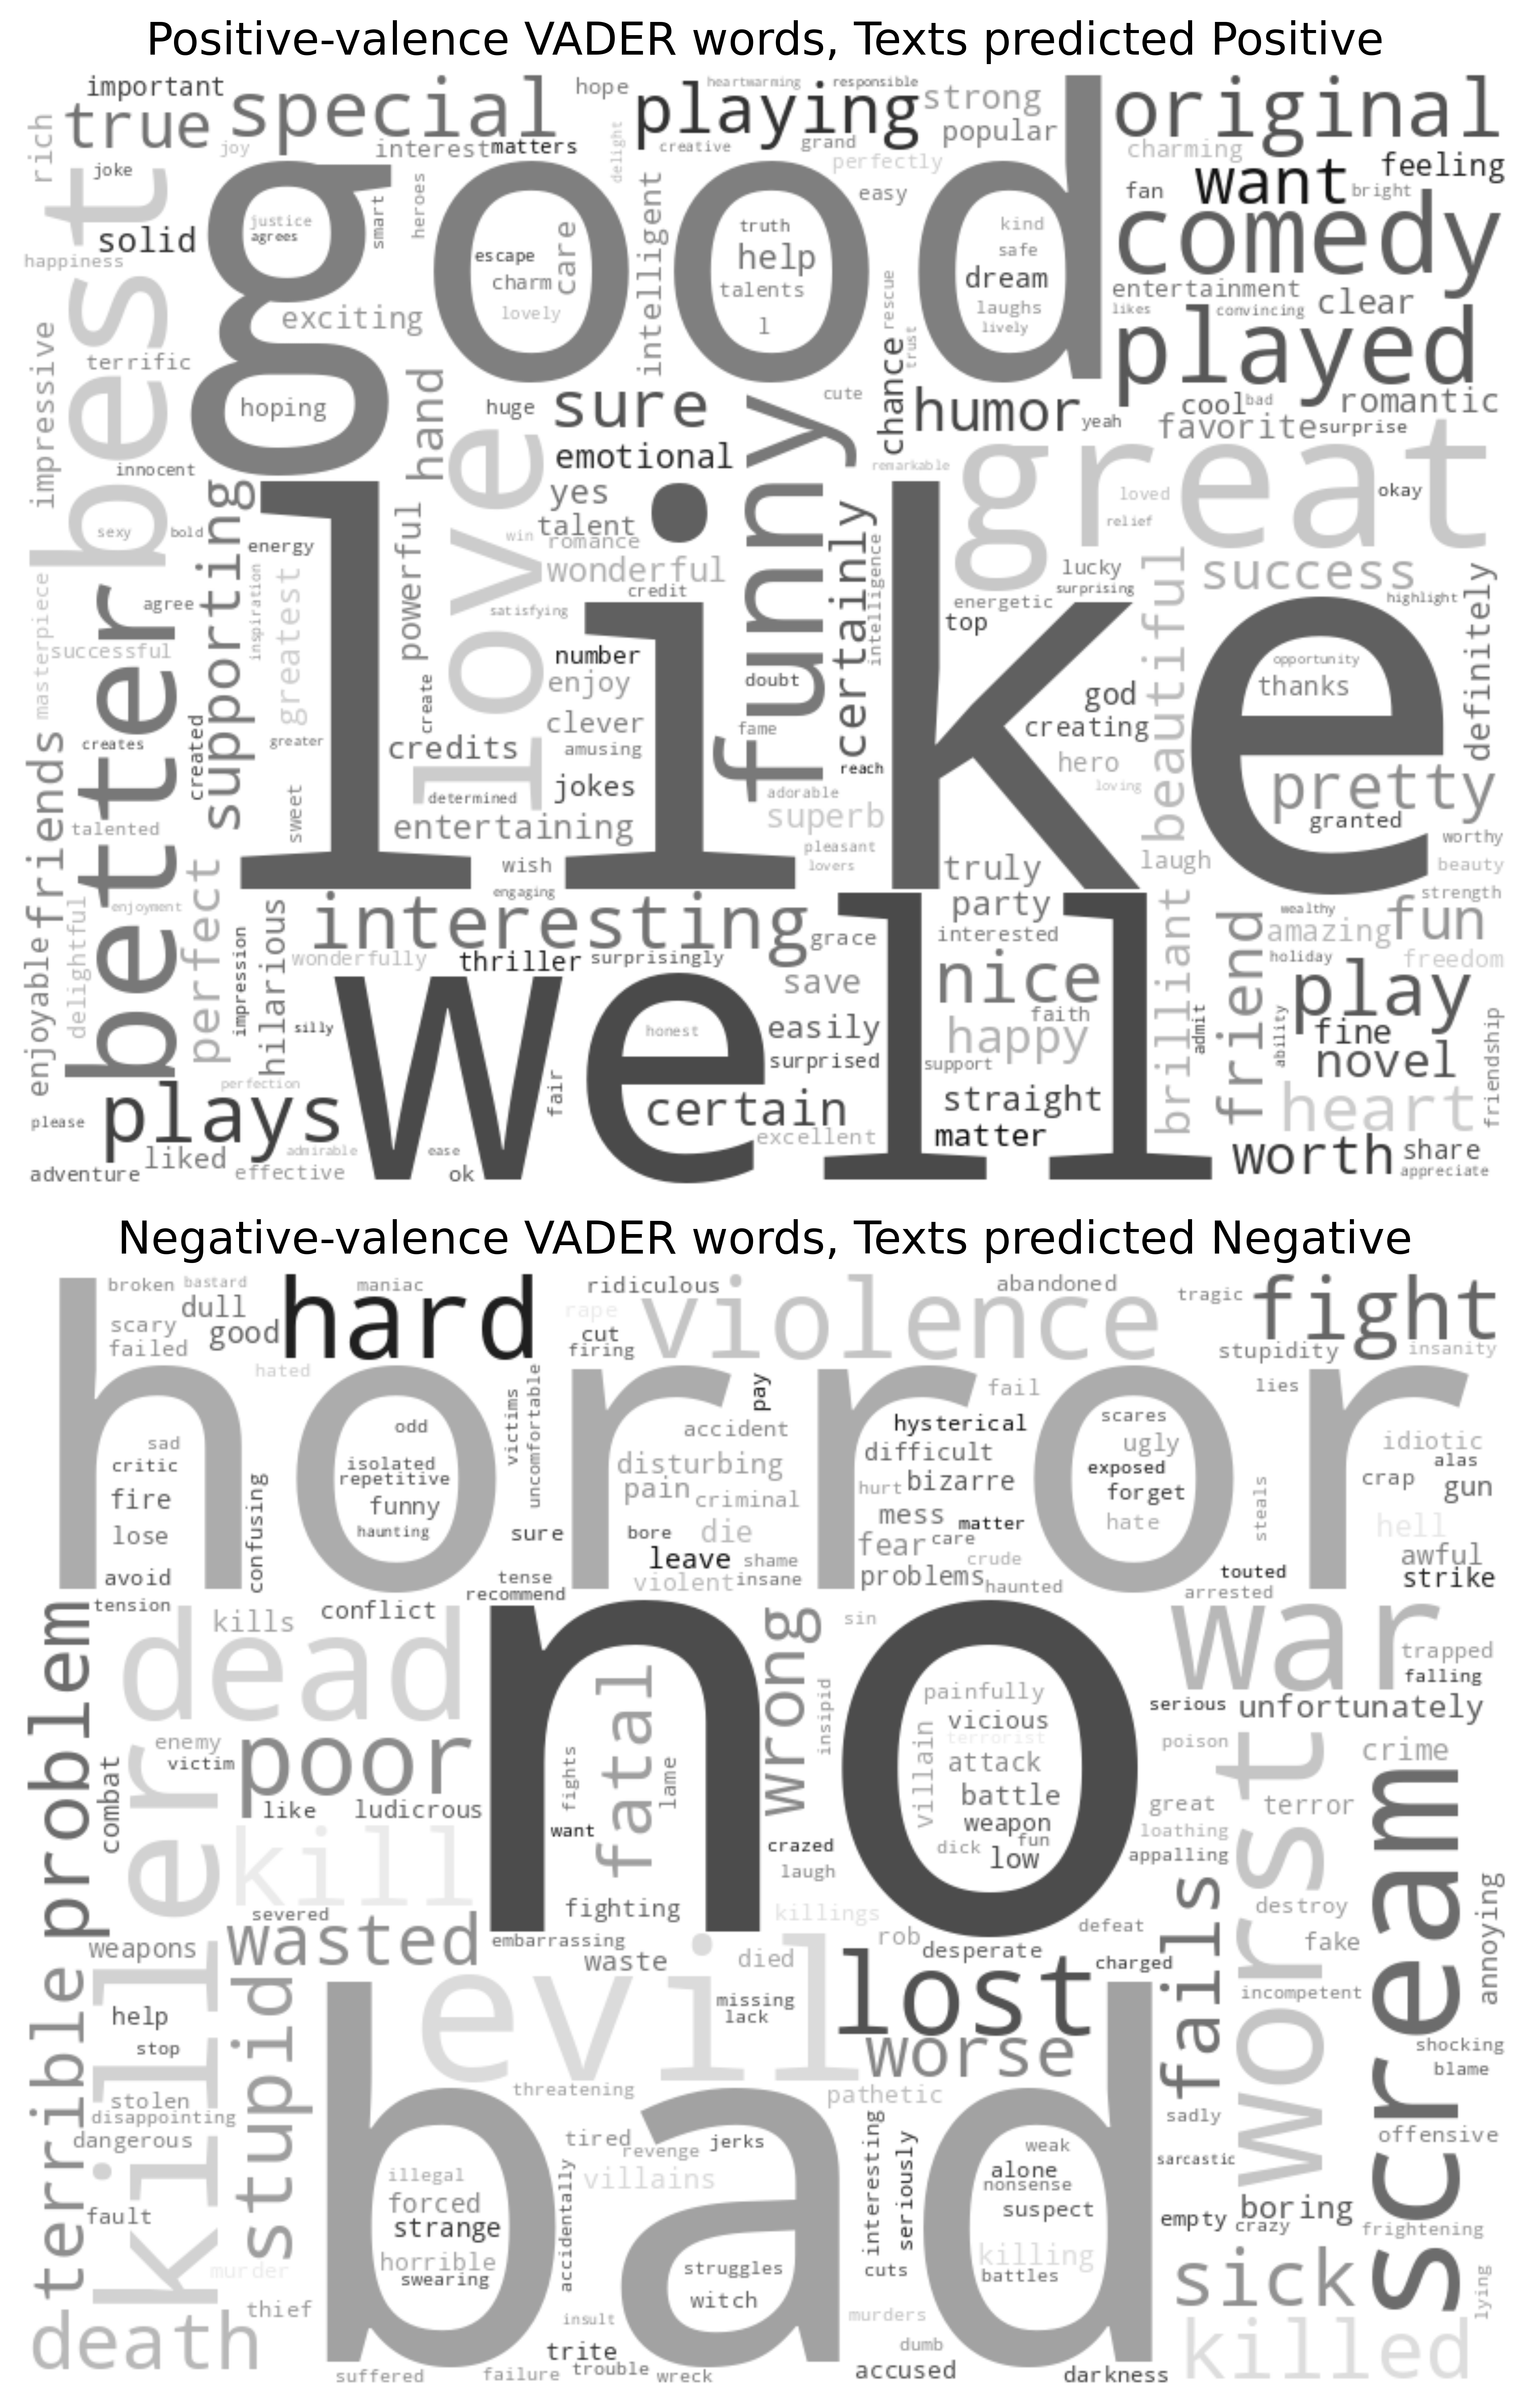

In [ ]:
#| eval: false
sentiment_wordcloud(texts, plot_mode = 'class_valence')

## Experimental: Extract sentiment profile features (VADER scores across a document) 

In [ ]:
#| export
class VaderSentimentProfileExtractor(BaseEstimator, TransformerMixin):
	""" Sci-kit Learn pipeline component to extract document-level sentiment profiles 
	consisting of document-level and sentence-level features with their order in the 
	document represented using VADER. 
	(This class is experimental and there may be breaking changes in the future). """
	def __init__(self, 
			  feature_store:TextFeatureStore = None, # (not implemented currently)
			  output:str = 'profile', # the feature output options are documented below. Valid values: 'profile' (default), 'profileonly', 'profilesections', 'profileallstats'
			  profile_first_n:int = 3, # number of sentences at start of doc to profile (ignored for 'profilesections')
			  profile_last_n:int = 3, # number of sentences at end of doc to profile (ignored for 'profilesections')
			  profile_sample_n:int = 4, # number of sentences to sample from doc sentences after first and last removed (ignored for 'profilesections')
			  profile_min_sentence_chars:int = 10, # minimum number of characters in body sentences for a sentence to be considered for the profile (ignored for 'profilesections')
			  profile_sections:int = 10, # number of sections to split the document into for profiling (for 'profilesections' only)
			):
		
		self.feature_store = feature_store
		if output not in ['profile', 'profilesections', 'profileallstats', 'profileonly']: 
			raise ValueError(f"output must be one of ['profile', 'profilesections', 'profileallstats', 'profileonly'], got {output}")
		self.output = output
		self.profile_first_n = profile_first_n
		self.profile_last_n = profile_last_n
		self.profile_sample_n = profile_sample_n
		self.profile_min_sentence_chars = profile_min_sentence_chars
		self.profile_sections = profile_sections

		# seeding random number generator for reproducibility
		np.random.seed(55)
		try:
			nltk.data.find('tokenizers/punkt_tab')
		except LookupError:
			nltk.download('punkt_tab')

		self.analyzer_ = SentimentIntensityAnalyzer()

`VaderSentimentProfileExtractor` extracts features from sentences or sections within longer documents. This is experimental functionality. There a number of different options for extracting features from a document:

* `profile` (default): Extracts a document sentiment profile vector of VADER's compound polarity score for the document, the proportion of positive, negative, and neutral across the whole document, and compound scores of sentences in the introduction, body and conclusion of the document.
* `profileonly`: Extracts a document sentiment profile vector based on the compound score of sentences in the introduction, body and conclusion of the document.
* `profileallstats`: Extracts a document sentiment vector of VADER's compound polarity score for the document, the proportion of positive, negative, and neutral across the whole document, and compound scores and pos/neg/neu proportions of sentences in the introduction, body and conclusion of the document.
* `profilesections`: Extracts a document sentiment vector by pooling sentences from the document into sections. Mean scores are calculated for each section, with `profile_sections` determining the number of sections per document. 

In [ ]:
#| export
@patch
def fit(self:VaderSentimentProfileExtractor, X, y=None):
	""" Fit is implemented, but does nothing. """
	return self

In [ ]:
#| export
@patch
def section_profile(self:VaderSentimentProfileExtractor, text):
	""" Mean pooling of VADER scores across document sections . """
	
	sentences = sent_tokenize(text)
	sentiment_scores = [self.analyzer_.polarity_scores(sentence)['compound'] for sentence in sentences]

	sentiment_scores = np.array(sentiment_scores)

	X_meanpooled = [np.mean(chunk) if len(chunk) > 0 else 0
					for chunk in np.array_split(sentiment_scores, self.profile_sections)]
	X_meanpooled = np.array(X_meanpooled)
	return X_meanpooled

In [ ]:
#| export
@patch
def profile(self:VaderSentimentProfileExtractor, 
				text: str, # the document text
				doc_level_scores: dict, # VADER scores for document text
				) -> list[float]: # a document profile vector consisting of the document level scores and sentence-level scores across the document
	""" Create a document profile with VADER scores, which makes use of document level scores and sentence-level scores across the document. """
	sentences = sent_tokenize(text)
	if self.output == 'profileonly':
		scores = []
	else:
		scores = [doc_level_scores['compound'], doc_level_scores['neg'], doc_level_scores['neu'], doc_level_scores['pos']]
	sentences_to_score = []
	if len(sentences) < self.profile_first_n + self.profile_last_n + self.profile_sample_n:
		if len(sentences) < self.profile_first_n: ## padding to end of start if needed
			sentences = sentences + [''] * (self.profile_first_n + self.profile_last_n + self.profile_sample_n - len(sentences))
		elif len(sentences) < self.profile_first_n + self.profile_last_n: # # padding to start of end if needed
			sentences = sentences[:self.profile_first_n] + [''] * (self.profile_first_n + self.profile_last_n + self.profile_sample_n - len(sentences)) + sentences[self.profile_first_n:]
		else:
			sentences = sentences[:self.profile_first_n] + sentences[self.profile_first_n:-self.profile_last_n] + [''] * (self.profile_first_n + self.profile_last_n + self.profile_sample_n - len(sentences)) + sentences[-self.profile_last_n:]

	if self.profile_min_sentence_chars > 0 and len(sentences) > self.profile_first_n + self.profile_last_n + self.profile_sample_n:
		overlap = len(sentences) - self.profile_first_n - self.profile_last_n - self.profile_sample_n
		for i in range(self.profile_first_n, len(sentences) - self.profile_last_n):
			if len(sentences[i].strip()) < self.profile_min_sentence_chars:
				sentences[i] = None
				overlap -= 1
				if overlap == 0:
					break
		sentences = [sentence for sentence in sentences if sentence is not None]

	sentences_to_score.extend(sentences[:self.profile_first_n])
	sentences_to_score.extend(sentences[-self.profile_last_n:])
	sentences = sentences[self.profile_first_n:-self.profile_last_n]
	if len(sentences) == self.profile_sample_n:
		sentences_to_score.extend(sentences)
	elif len(sentences) > self.profile_sample_n:
		sample_indices = np.random.choice(len(sentences), self.profile_sample_n, replace=False)
		sample_indices.sort()
		sentences_to_score.extend([sentences[i] for i in sample_indices])
	del sentences

	for i, sentence in enumerate(sentences_to_score):
		if self.output == 'profileallstats':
			sentence_scores = self.analyzer_.polarity_scores(sentence)
			scores.extend([sentence_scores['compound'], sentence_scores['neg'], sentence_scores['neu'], sentence_scores['pos']])
		else:
			scores.append(self.analyzer_.polarity_scores(sentence)['compound'])

	if self.output =='profile' and len(scores) < 4 + self.profile_first_n + self.profile_last_n + self.profile_sample_n:
		print('scores')
		print(scores)
		print('sentences to score')	
		print(sentences_to_score)
		print('full text')
		print(text)
		raise ValueError(f"VADER profile vector is too short")

	return scores

In [ ]:
#| export
@patch
def transform(self:VaderSentimentProfileExtractor, X):
	""" Extracts the sentiment from the text using VADER. """
	results = []
	for text in X:
		scores = self.analyzer_.polarity_scores(text)
		if self.output == 'profilesections':
			results.append(self.section_profile(text))
		else:
			results.append(self.profile(text, scores))
	return np.atleast_2d(results)  # Ensure the output is always a 2D array

In [ ]:
#| export
@patch
def get_feature_names_out(self:VaderSentimentProfileExtractor, input_features=None):
	""" Get the feature names out from the model. """
	if self.output == 'profileonly':
		return [f'introduction_sentence_{i}' for i in range(self.profile_first_n)] + [f'conclusion_sentence_{i}' for i in range(self.profile_last_n)] + [f'body_sentence_sample_{i}' for i in range(self.profile_sample_n)]
	elif self.output == 'profileallstats':
		return ['doc_compound', 'doc_negative', 'doc_neutral', 'doc_positive'] + [f'introduction_sentence_{i}_compound' for i in range(self.profile_first_n)] + [f'introduction_sentence_{i}_negative' for i in range(self.profile_first_n)] + [f'introduction_sentence_{i}_neutral' for i in range(self.profile_first_n)] + [f'introduction_sentence_{i}_positive' for i in range(self.profile_first_n)] + [f'conclusion_sentence_{i}_compound' for i in range(self.profile_last_n)] + [f'conclusion_sentence_{i}_negative' for i in range(self.profile_last_n)] + [f'conclusion_sentence_{i}_neutral' for i in range(self.profile_last_n)] + [f'conclusion_sentence_{i}_positive' for i in range(self.profile_last_n)] + [f'body_sentence_sample_{i}_compound' for i in range(self.profile_sample_n)] + [f'body_sentence_sample_{i}_negative' for i in range(self.profile_sample_n)] + [f'body_sentence_sample_{i}_neutral' for i in range(self.profile_sample_n)] + [f'body_sentence_sample_{i}_positive' for i in range(self.profile_sample_n)]
	elif self.output == 'profilesections':
		return [f'section_{i}' for i in range(self.profile_sections)]
	else: # 'profile'
		return ['doc_compound', 'doc_negative', 'doc_neutral', 'doc_positive'] + [f'introduction_sentence_{i}' for i in range(self.profile_first_n)] + [f'conclusion_sentence_{i}' for i in range(self.profile_last_n)] + [f'body_sentence_sample_{i}' for i in range(self.profile_sample_n)]


In [ ]:
#| export
@patch
def plot_sentiment_structure(self: VaderSentimentProfileExtractor, 
                             X: list[str], 
                             y: list, 
                             target_classes: list = None, 
                             target_names: list = None,
                             n_clusters:int = 5, # Number of clusters per class
                             samples_per_cluster:int = 5, # number of samples to plot per cluster
                             renderer:str='svg', # 'svg' or 'png'
                             ):
    """
    Plot the sentiment structure of documents. Requires the VaderSentimentProfileExtractor to be instantiated with 
    output='profilesections' or 'profileonly'. For each class, cluster the documents by sentiment structure into n_clusters, and plot up to samples_per_cluster.
    (Experimental feature, will change in future).
    """
    if self.output not in ['profileonly', 'profilesections']:
        print(f"plot_sentiment_structure is only supported for output='profileonly' or output='profilesections'")
        return

    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import matplotlib.colors as mcolors
    import numpy as np
    from matplotlib.colors import LinearSegmentedColormap
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    from textplumber.report import plt_svg

    n_labels = len(target_classes)
    cluster_gap = 1  # Space between clusters (in y units)

    # Figure sizing
    size_scaler = 8
    fig = plt.figure(figsize=(20, size_scaler * n_labels + 1))
    import matplotlib.gridspec as gridspec
    gs = gridspec.GridSpec(n_labels, 1, hspace=0.2)
    axes = [fig.add_subplot(gs[i, 0]) for i in range(n_labels)]
    if n_labels == 1:
        axes = [axes]

    cmap = LinearSegmentedColormap.from_list('my_cmap', ['red', 'white', 'green'])
    norm = mcolors.Normalize(vmin=-1, vmax=1)
    bar_height = 1

    n_sections = self.profile_sections if self.output == 'profilesections' else self.profile_sample_n + self.profile_first_n + self.profile_last_n

    for idx, (label, ax) in enumerate(zip(target_classes, axes)):
        # Filter X for current label
        X_for_label = [X[i] for i in range(len(X)) if y[i] == label]
        if not X_for_label:
            continue

        X_features = self.transform(X_for_label)
        X_scaled = StandardScaler().fit_transform(X_features)

        # Cluster
        clusterer = KMeans(n_clusters=n_clusters, random_state=0).fit(X_scaled)
        labels_pred = clusterer.labels_

        # Plot up to 5 closest samples per cluster
        y_pos = 0  # Row counter for plotting
        for cluster_id in range(n_clusters, -1, -1):
            cluster_indices = np.where(labels_pred == cluster_id)[0]
            n_in_cluster = len(cluster_indices)
            if n_in_cluster == 0:
                continue
            # Find up to 5 closest to cluster center
            cluster_center = clusterer.cluster_centers_[cluster_id]
            distances = np.linalg.norm(X_scaled[cluster_indices] - cluster_center, axis=1)
            closest_indices = cluster_indices[np.argsort(distances)[:samples_per_cluster]]

            # Draw border around this cluster block (excluding the gap)
            cluster_block_top = y_pos
            cluster_block_height = len(closest_indices)
            rect_border = patches.Rectangle(
                (0, cluster_block_top), 1, cluster_block_height, 
                linewidth=0.1, edgecolor='black', facecolor='none', zorder=10
            )
            ax.add_patch(rect_border)

            # Label the cluster to the left, vertically centered on the block
            cluster_label_y = cluster_block_top + cluster_block_height / 2 - 0.5
            ax.text(0, cluster_label_y, 
                    f"Cluster {cluster_id} \n{n_in_cluster} samples", 
                    va='center', ha='right', fontsize=10, color='black',
                    transform=ax.transData)

            for k in closest_indices:
                sentiment_scores = X_features[k]
                for j, score in enumerate(sentiment_scores):
                    start = j / n_sections
                    width = 1 / n_sections
                    rect = patches.Rectangle(
                        (start, y_pos), width, bar_height, 
                        color=cmap(norm(score)), linewidth=0
                    )
                    ax.add_patch(rect)
                y_pos += 1  # Next row

            y_pos += cluster_gap  # Add gap after each cluster

        ax.set_xlim(0, 1)
        ax.set_ylim(0, y_pos)
        ax.set_yticks([])
        ax.set_xticks([])
        # Remove y axis label
        ax.set_ylabel('')
        ax.grid(False)
        if target_names:
            ax.set_title(f"{target_names[idx]}")
        # Remove all subplot borders (spines)
        for spine in ax.spines.values():
            spine.set_visible(False)
        # ax.set_xlabel("Position in Document", fontsize=12, labelpad=10)
        ax.xaxis.set_label_coords(0.95, -0.08)
        ax.set_xlabel('')

    # Add colorbar
    cax = fig.add_axes([0.78, 0.95, 0.1, 0.02])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, orientation='horizontal', label='Sentiment Score')
    cax.set_aspect(0.1)
    for spine in cax.spines.values():
        spine.set_linewidth(0.1)

    fig.suptitle("Sentiment structure of documents based on VADER predictions", fontsize=16, y=0.99)
    fig.text(0.08, 0.04, "Note: For each class, documents are clustered using KMeans by their sentence-level VADER sentiment structure. ", ha='left', fontsize=10, color='black')
    fig.text(0.08, 0.03, f"Cluster labels and count are shown on the left. Up to {samples_per_cluster} representative documents per cluster are represented for each cluster (one document per row).", ha='left', fontsize=10, color='black')
    if self.output == 'profilesections':
        fig.text(0.08, 0.02, f"Sentiment scores are pooled into {n_sections} sections across each document and these are represented in the order they appear in the document (i.e. left most are at start of document, right at end).", ha='left', fontsize=10, color='black')
    else:
        fig.text(0.08, 0.02, f"Sentiment scores are extracted from the first {self.profile_first_n} sentences, last {self.profile_last_n} sentences, and {self.profile_sample_n} sampled sentences in the document and these are represented in the order they appear in the document (i.e. left most are at start of document, right at end).", ha='left', fontsize=10, color='black')
    fig.text(0.08, 0.01, "The intensity of colors of each section represent the mean VADER compound score for sentences in that section. ", ha='left', fontsize=10, color='black')
    if renderer == 'svg':
        plt_svg(fig)
    else:
        plt.show()

Loading a dataset of longer texts to demonstrate ...

In [ ]:
#| eval: false
dataset_name = 'polsci/sentiment-polarity-dataset-v2.0'
dataset_dir = ''
dataset = load_dataset(dataset_name, data_dir = dataset_dir, split='train')

In [ ]:
#| eval: false
label_column = 'label'
target_names = get_label_names(dataset, label_column)
target_classes = list(range(len(target_names)))

df = dataset.to_pandas()
X = df['text']
y = df[label_column]

In [ ]:
#| eval: false
dataset_descriptor = 'Movie Reviews dataset (Sentiment Polarity Dataset v2.0), train/test randomly sampled (80/20) from original train split'
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

`VaderSentimentProfileExtractor` provides a way to visualise the sentiment structure of longer documents. This requires the output to be set to `profilesections` (for meanpooled scoring across the document) or `profileonly` (for scoring of sentences in the introduction, body and conclusion of the document). 

In [ ]:
#| eval: false
VaderSentimentProfileExtractor(output = 'profileonly').plot_sentiment_structure(X, y, target_classes = target_classes, target_names = target_names)

In [ ]:
#| hide
if os.path.exists('results_example_vader_profiles.csv'):
    os.remove('results_example_vader_profiles.csv')

Below the `VaderSentimentProfileExtractor` is compared with VADER scoring of the whole text, using `VaderSentimentEstimator`, and a classifier that uses VADER statistics as features, using `VaderSentimentExtractor`. 

In [ ]:
#| eval: false
pipelines = {
	'Standard VADER algorithm': Pipeline([
			('classifier', VaderSentimentEstimator(output = 'labels', neutral_threshold = 0, label_mapping = {'positive': 1, 'negative': 0})),
		]),
	'LR classifier using VADER document-level scores': Pipeline([
			('vader_extractor', VaderSentimentExtractor(output = 'allstats')),
			('classifier', LogisticRegression(max_iter = 5000, random_state=55))
		]),
	'LR classifier using profilesections':
			Pipeline([
			('vader_extractor', VaderSentimentProfileExtractor(output='profilesections')),
			('classifier', LogisticRegression(max_iter = 5000, random_state=55))
		]),
	'LR classifier using profileonly':
			Pipeline([
			('vader_extractor', VaderSentimentProfileExtractor(output='profileonly')),
			('classifier', LogisticRegression(max_iter = 5000, random_state=55))
		]),
	'LR classifier using profileallstats': Pipeline([
			('vader_extractor', VaderSentimentProfileExtractor(output='profileallstats')),
			('classifier', LogisticRegression(max_iter = 5000, random_state=55))
		]),
	'LR classifier using profile':
			Pipeline([
			('vader_extractor', VaderSentimentProfileExtractor(output='profile')),
			('classifier', LogisticRegression(max_iter = 5000, random_state=55))
		]),
}

for experiment_descriptor, pipeline in pipelines.items():
	print(f"Running experiment: {experiment_descriptor}")
	pipeline.fit(X_train, y_train)
	y_pred = pipeline.predict(X_test)
	results = save_results('results_example_vader_profiles.csv', pipeline, experiment_descriptor, dataset_descriptor, y_test, y_pred, target_classes, target_names, classifier_step_name = 'classifier')

Running experiment: Standard VADER algorithm
Running experiment: LR classifier using VADER document-level scores
Running experiment: LR classifier using profilesections
Running experiment: LR classifier using profileonly
Running experiment: LR classifier using profileallstats
Running experiment: LR classifier using profile


The results of the experiments are summarised below. On the long texts used for this experiment, all profile-based classifiers using `VaderSentimentProfileExtractor` perform better than the two baselines (Standard VADER scoring, VADER document scores as classifier features). The best results are achieved for the `profile` default output option, which combined document-level scores with sentence-level scores across the document.

In [ ]:
#| eval: false
fields = ['experiment', 'accuracy_f1', 'neg_f1', 'pos_f1']
display(pd.read_csv('results_example_vader_profiles.csv').sort_values(by='accuracy_f1', ascending=False)[fields])

,experiment,accuracy_f1,neg_f1,pos_f1
5,LR classifier using profile,0.7150,0.710660,0.719212
3,LR classifier using profileonly,0.6850,0.688119,0.681818
2,LR classifier using profilesections,0.6775,0.692124,0.661417
4,LR classifier using profileallstats,0.6750,0.673367,0.676617
1,LR classifier using VADER document-level scores,0.6575,0.600583,0.700219
0,Standard VADER algorithm,0.6450,0.567073,0.699153


A plot of most discriminative features for the classifier using `VaderSentimentProfileExtractor` and the `profile` feature output option is included below. VADER scores (doc_positive, doc_negative, doc_neutral, and doc_compound) for the whole document are discriminative features. Sentiment scores for sentences from the conclusion are helpful to discriminate overall sentiment of the text relative to sentence scores for other parts of the texts. 

In [ ]:
#| eval: false
plot_logistic_regression_features_from_pipeline(pipeline, target_classes, target_names, top_n=20, classifier_step_name = 'classifier', features_step_name = 'vader_extractor')

,Feature,Log Odds (Logit),Odds Ratio
3,doc_positive,2.244448,9.435208
1,doc_negative,-1.303382,0.271612
2,doc_neutral,-0.905903,0.404177
9,conclusion_sentence_2,0.851913,2.344126
7,conclusion_sentence_0,0.505986,1.658621
8,conclusion_sentence_1,0.410974,1.508286
0,doc_compound,0.403546,1.497125
12,body_sentence_sample_2,0.277697,1.320086
6,introduction_sentence_2,0.262118,1.299679
10,body_sentence_sample_0,0.202882,1.224928


In [ ]:
#| hide
# from imdb dataset hf
# test_text = """
# I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, even then it's not shot like some cheaply made porno. While my countrymen mind find it shocking, in reality sex and nudity are a major staple in Swedish cinema. Even Ingmar Bergman, arguably their answer to good old boy John Ford, had sex scenes in his films.<br /><br />I do commend the filmmakers for the fact that any sex shown in the film is shown for artistic purposes rather than just to shock people and make money to be shown in pornographic theaters in America. I AM CURIOUS-YELLOW is a good film for anyone wanting to study the meat and potatoes (no pun intended) of Swedish cinema. But really, this film doesn't have much of a plot.
# """
# test_text = """
# This movie was just plain bad. Just about every cop movie cliché is present and accounted for. Bad guy gets away? check. Partner? check. Wacky personality clash with partner? check. Rookie with something to prove? check. Rookie shows up grizzled veteran. check. About the only ones it didn't touch on were idiot shoot themselves in the foot and retirony but I guess they're saving those old chestnuts for Dooley's next outing. Add in the battle of the sexes with Girl Power along with tired old sight gags and banal overdone material like Dooley's prize car getting trashed all the time and you have the recipe for one really bad movie. Avoid this one at all costs.
# """
# extractor = VaderSentimentExtractor(output='profile')
# print(extractor.transform([test_text]))
# extractor = VaderSentimentExtractor(output='profile', profile_min_sentence_chars=1)
# test_texts = ['good. good.', 'good. good. good. bad. ', 'good. good. good. bad. bad. bad.', 'good. good. good. great. bad. bad. bad.', 'good. good. good. great. great. great. bad. bad. bad.', 'good. good. good. great. greater. greatest. very great. very greatest. bad. bad. bad.']
# print(extractor.transform(test_texts))

## Experimental: Extract sentiment-tagged ngrams as features 

In [ ]:
#| export
class VaderSentimentPOSNgramsExtractor(BaseEstimator, TransformerMixin):
	""" Sci-kit Learn pipeline component to extract ngrams based on POS 
	tags and sentiment from VADER lexicon.
	(This class is experimental and there may be breaking changes in the future, 
	including the possibility of complete removal). """
	def __init__(self, 
			  feature_store:TextFeatureStore = None, # (not implemented currently)
			  output:str = 'sentimentposngrams', # sentimentposngrams or sentintensityposngrams, this is experimental and likely to change
			  ngram_range:tuple = (2, 2), # ngram range for POS ngrams
			):
		
		self.feature_store = feature_store
		if output not in ['sentimentposngrams', 'sentintensityposngrams']: 
			raise ValueError(f"output must be one of ['sentimentposngrams', 'sentintensityposngrams'], got {output}")
		self.output = output
		self.ngram_range = ngram_range

		self.analyzer_ = SentimentIntensityAnalyzer()

In [ ]:
#| export
@patch
def convert_score_to_token_label(self:VaderSentimentPOSNgramsExtractor, 
								 score: float) -> str:
	""" Convert VADER score to a token label (experimental). """
	if score < 0:
		label = 'SENT_NEG'
	else:
		label = 'SENT_POS'
	if self.output == 'sentintensityposngrams':
		label += str(int(abs(score)))
	return label

In [ ]:
#| export
@patch
def get_sentiment_pos_ngrams(self:VaderSentimentPOSNgramsExtractor,
	text):
	""" Get ngrams of POS features and lexicon+pos features (experimental).  """
	doc_tokens = self.feature_store.get_tokens_from_texts([text])[0]
	doc_tokens = [token.lower() for token in doc_tokens]

	doc_pos = self.feature_store.get_pos_from_texts([text])[0]
	lexicon_words = list(self.analyzer_.lexicon.keys())
	lexicon_words_in_doc = list(set(doc_tokens).intersection(set(lexicon_words)))
	lexicon_labels = [self.convert_score_to_token_label(self.analyzer_.lexicon[word]) for word in lexicon_words_in_doc]
	# append lexicon labels to doc_pos at the same index as the lexicon words
	for i, token in enumerate(doc_tokens):
		if token in lexicon_words_in_doc:
			doc_pos[i] = lexicon_labels[lexicon_words_in_doc.index(token)] + '_' + doc_pos[i]
	return doc_pos


In [ ]:
#| export
@patch
def fit(self:VaderSentimentPOSNgramsExtractor, X, y=None):
	""" Fit derives all ngrams. """
	X_raw = []
	for text in X:
		X_raw.append(self.get_sentiment_pos_ngrams(text))
	self.vectorizer_ = CountVectorizer(tokenizer=pass_tokens,
								lowercase=False, 
								stop_words=None, 
								token_pattern=None, 
								min_df=1,
								max_df=1.0,
								max_features=None,
								ngram_range=self.ngram_range,
								vocabulary= None)
	self.vectorizer_.fit(X_raw)
	vocab = self.vectorizer_.get_feature_names_out()
	# if ngram doesn't contain SENT_ then removing here
	vocab = [x for x in vocab if 'SENT_' in x]
	# reminder: double-pass here is to remove all non-SENT_ ngrams - so only creating features derived from lexicon
	self.vectorizer_ = CountVectorizer(tokenizer=pass_tokens, 
								lowercase=False, 
								stop_words=None, 
								token_pattern=None, 
								min_df=1,
								max_df=1.0,
								max_features=None,
								ngram_range=self.ngram_range,
								vocabulary= vocab)
	self.vectorizer_.fit(X_raw)
	return self

In [ ]:
#| export
@patch
def transform(self:VaderSentimentPOSNgramsExtractor, X):
	""" Transform into sentiment ngrams. """
	results = []
	for text in X:
		results.append(self.get_sentiment_pos_ngrams(text))
	results = self.vectorizer_.transform(results)
	results = results.toarray()
	return np.atleast_2d(results)  # Ensure the output is always a 2D array

In [ ]:
#| export
@patch
def get_feature_names_out(self:VaderSentimentPOSNgramsExtractor, input_features=None):
	""" Get the feature names out from the model. """
	return self.vectorizer_.get_feature_names_out()


In [ ]:
#| hide
# from textplumber.store import TextFeatureStore
# from textplumber.preprocess import SpacyPreprocessor
# from sklearn.pipeline import Pipeline, FeatureUnion
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report

# from datasets import load_dataset
# from sklearn.model_selection import train_test_split

# import pandas as pd
# feature_store = TextFeatureStore('vader-sentimentposngrams.sqlite')
# feature_store.dump()
# pipeline = Pipeline([
#     ('preprocess', SpacyPreprocessor(feature_store=feature_store, pos_tagset='detailed')),
#     #('vader', VaderSentimentExtractor(feature_store=feature_store, output='sentimentposbigrams')),
#     ('vader', VaderSentimentExtractor(feature_store=feature_store, output='sentintensityposbigrams')),
#     #('classifier', LogisticRegression(max_iter=5000, random_state=0))
# ])
# X = ['This is a bad movie.', 'This is a good movie.', 'This is a bad bad terrible movie.', 'This is a very great movie.']
# pipeline.fit(X)
# X_transformed = pipeline.transform(X)
# print(X_transformed)
# print(pipeline.named_steps['vader'].get_feature_names_out())

In [ ]:
#| hide
if os.path.exists('feature_store_example_vader.sqlite'):
	os.remove('feature_store_example_vader.sqlite')
if os.path.exists('vader-sentimentposngrams.sqlite'):
	os.remove('vader-sentimentposngrams.sqlite')

In [ ]:
#| hide
if os.path.exists('results_example_vader.csv'):
	os.remove('results_example_vader.csv')
if os.path.exists('results_example_vader_profiles.csv'):
	os.remove('results_example_vader_profiles.csv')

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()